# Linear cellular sheaves, Gate 1: the smallest useful example

This notebook builds a cellular sheaf on a three-node path. It is deliberately smaller than the barcode problem: the goal is to understand each mathematical object before introducing overlapping barcode windows.

By the end of this gate, we will be able to explain and compute:

- vertex and edge **stalks**;
- **restriction maps** from vertices to incident edges;
- the **coboundary** $\delta$ and sheaf Laplacian $L_{\mathcal F}=\delta^\top\delta$;
- compatible assignments, or **global sections**;
- pure diffusion versus confidence-weighted recovery.

> Scope boundary: this gate stops at scalar consensus. It does not yet model barcode bars, blur, or multiple scanlines.

In [1]:
import platform
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

SEED = 7
rng = np.random.default_rng(SEED)

print(f'Python: {platform.python_version()}')
print(f'NumPy: {np.__version__}')
print(f'Matplotlib: {matplotlib.__version__}')
print(f'Executable: {sys.executable}')
print(f'Random seed: {SEED}')

Python: 3.12.3
NumPy: 1.26.4
Matplotlib: 3.6.3
Executable: /usr/bin/python3
Random seed: 7


## 1. Put local data on a graph

Our base space is the path $v_0 \rightarrow v_1 \rightarrow v_2$, with edges $e_0=(v_0,v_1)$ and $e_1=(v_1,v_2)$.

Every vertex and edge receives a one-dimensional real vector space $\mathbb R$ as its stalk. Both restriction maps incident to an edge are the identity. Therefore, two neighboring vertex values are compatible exactly when they are equal.

For an oriented edge $e=(u,v)$, the coboundary records disagreement:

$$
(\delta x)_e = \mathcal F_{v\to e}x_v - \mathcal F_{u\to e}x_u = x_v-x_u.
$$

Coboundary delta:
[[-1.  1.  0.]
 [ 0. -1.  1.]]

Sheaf Laplacian L = delta.T @ delta:
[[ 1. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  1.]]


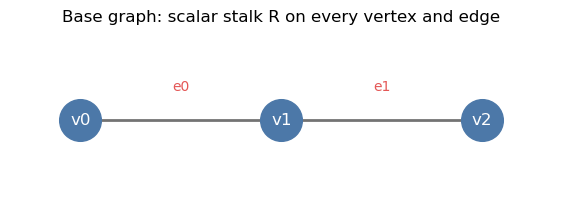

In [2]:
vertices = ('v0', 'v1', 'v2')
edges = (('v0', 'v1'), ('v1', 'v2'))

# Rows correspond to oriented edges; columns correspond to vertices.
delta = np.array([
    [-1.0,  1.0,  0.0],
    [ 0.0, -1.0,  1.0],
])
L = delta.T @ delta

print('Coboundary delta:')
print(delta)
print('\nSheaf Laplacian L = delta.T @ delta:')
print(L)

fig, ax = plt.subplots(figsize=(7, 2.2))
positions = np.array([[0.0, 0.0], [1.0, 0.0], [2.0, 0.0]])
ax.plot(positions[:, 0], positions[:, 1], color='0.45', linewidth=2, zorder=1)
ax.scatter(positions[:, 0], positions[:, 1], s=900, color='#4C78A8', zorder=2)
for (x_pos, y_pos), label in zip(positions, vertices):
    ax.text(x_pos, y_pos, label, ha='center', va='center', color='white', fontsize=12)
for edge_index, midpoint in enumerate((0.5, 1.5)):
    ax.text(midpoint, 0.13, f'e{edge_index}', ha='center', color='#E45756')
ax.set(xlim=(-0.35, 2.35), ylim=(-0.35, 0.4), title='Base graph: scalar stalk R on every vertex and edge')
ax.axis('off')
plt.show()

## 2. Compatibility, energy, and global sections

A vertex assignment $x=(x_0,x_1,x_2)$ is a global section when every overlap agrees, so $\delta x=0$. The constant assignment is compatible; a nonconstant assignment is not.

The total disagreement energy has two equivalent forms:

$$
E(x)=\lVert\delta x\rVert_2^2=x^\top L_{\mathcal F}x.
$$

Because $L_{\mathcal F}=\delta^\top\delta$, it is symmetric positive semidefinite. Its zero-eigenvalue eigenvectors are precisely the global sections in this example.

In [3]:
x_global = np.array([1.0, 1.0, 1.0])
x_inconsistent = np.array([1.0, -0.5, 0.8])

def consistency_energy(x):
    return float(np.linalg.norm(delta @ x) ** 2)

eigenvalues = np.linalg.eigvalsh(L)

print(f'delta @ global section: {delta @ x_global}')
print(f'delta @ inconsistent assignment: {delta @ x_inconsistent}')
print(f'inconsistent energy: {consistency_energy(x_inconsistent):.3f}')
print(f'Laplacian eigenvalues: {eigenvalues}')

assert delta.shape == (2, 3)
assert L.shape == (3, 3)
assert np.allclose(L, L.T)
assert np.all(eigenvalues >= -1e-12)
assert np.count_nonzero(np.isclose(eigenvalues, 0.0, atol=1e-12)) == 1
assert np.allclose(delta @ x_global, 0.0)
assert np.isclose(consistency_energy(x_inconsistent), x_inconsistent @ L @ x_inconsistent)

delta @ global section: [0. 0.]
delta @ inconsistent assignment: [-1.5  1.3]
inconsistent energy: 3.940
Laplacian eigenvalues: [3.92505363e-17 1.00000000e+00 3.00000000e+00]


## 3. Diffusion is not the same as restoration

The update $x_{t+1}=x_t-\alpha L_{\mathcal F}x_t$ decreases disagreement when the step size is stable. With this connected identity sheaf, however, pure diffusion ultimately keeps only the mean of the initial observations. It has no term requiring the result to explain trusted measurements.

For restoration, add data fidelity and confidence. Let $y$ be the measurements and $W=\operatorname{diag}(w_i)$ their confidence matrix. We solve

$$
\hat x=\arg\min_x (x-y)^\top W(x-y)+\lambda x^\top L_{\mathcal F}x,
$$

whose unique solution for positive confidence is

$$
(W+\lambda L_{\mathcal F})\hat x=Wy.
$$

In [4]:
truth = np.ones(3)
observed = np.array([1.05, -0.80, 0.90])  # The center measurement is corrupted.
confidence = np.array([1.0, 0.03, 1.0])
W = np.diag(confidence)
regularization = 1.0

weighted_solution = np.linalg.solve(W + regularization * L, W @ observed)
unweighted_solution = np.linalg.solve(np.eye(3) + regularization * L, observed)

alpha = 0.25  # Stable because alpha < 2 / largest_eigenvalue(L).
diffused = observed.copy()
diffusion_history = [diffused.copy()]
for _ in range(40):
    diffused = diffused - alpha * (L @ diffused)
    diffusion_history.append(diffused.copy())
diffusion_history = np.asarray(diffusion_history)

def weighted_data_error(x):
    residual = x - observed
    return float(residual @ W @ residual)

print(f'truth:               {truth}')
print(f'observed:            {observed}')
print(f'pure diffusion:      {diffused.round(4)}')
print(f'unweighted solution: {unweighted_solution.round(4)}')
print(f'weighted solution:   {weighted_solution.round(4)}')
print()
print(f'observed consistency energy: {consistency_energy(observed):.4f}')
print(f'weighted consistency energy: {consistency_energy(weighted_solution):.4f}')
print(f'weighted data error:          {weighted_data_error(weighted_solution):.4f}')

assert np.all(np.isfinite(weighted_solution))
assert consistency_energy(diffused) < consistency_energy(observed)
assert consistency_energy(weighted_solution) < consistency_energy(observed)
assert np.linalg.norm(weighted_solution - truth) < np.linalg.norm(observed - truth)

truth:               [1. 1. 1.]
observed:            [ 1.05 -0.8   0.9 ]
pure diffusion:      [0.3833 0.3833 0.3833]
unweighted solution: [0.5688 0.0875 0.4938]
weighted solution:   [0.9867 0.9233 0.9117]

observed consistency energy: 6.3125
weighted consistency energy: 0.0041
weighted data error:          0.0932


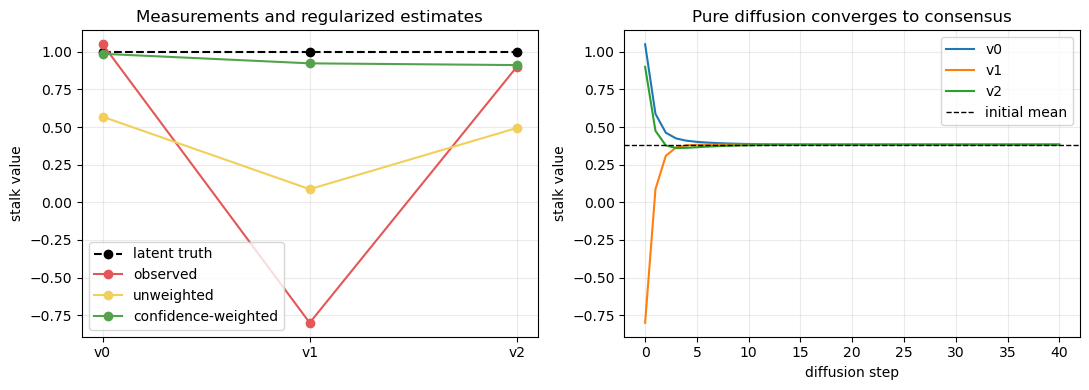

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

module_index = np.arange(3)
axes[0].plot(module_index, truth, 'k--', marker='o', label='latent truth')
axes[0].plot(module_index, observed, color='#E45756', marker='o', label='observed')
axes[0].plot(module_index, unweighted_solution, color='#F2CF5B', marker='o', label='unweighted')
axes[0].plot(module_index, weighted_solution, color='#54A24B', marker='o', label='confidence-weighted')
axes[0].set(xticks=module_index, xticklabels=vertices, ylabel='stalk value', title='Measurements and regularized estimates')
axes[0].legend()
axes[0].grid(alpha=0.25)

for vertex_index, vertex in enumerate(vertices):
    axes[1].plot(diffusion_history[:, vertex_index], label=vertex)
axes[1].axhline(observed.mean(), color='k', linestyle='--', linewidth=1, label='initial mean')
axes[1].set(xlabel='diffusion step', ylabel='stalk value', title='Pure diffusion converges to consensus')
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

## 4. What this teaches—and what it does not

We now have the complete linear cellular-sheaf pipeline in miniature:

1. the graph says which local data interact;
2. stalks say what data live at each graph cell;
3. restriction maps say what neighboring data must agree about;
4. $\delta$ measures every local disagreement;
5. $L_{\mathcal F}$ aggregates those disagreements;
6. confidence-weighted regularization balances agreement with evidence.

The restriction maps are the modeling decision. Identity maps on scalar stalks demand equality everywhere, which is useful for learning consensus but wrong for a barcode: neighboring barcode modules are allowed to differ. The next gate should use vector stalks for overlapping windows and coordinate-selection restriction maps. Those maps will require agreement only where two windows describe the same underlying module.

Gate 1 intentionally stops here. Gate 2 begins below only after review.

### Reference

Jakob Hansen and Robert Ghrist, [*Toward a Spectral Theory of Cellular Sheaves*](https://arxiv.org/abs/1808.01513).

# Gate 2: overlapping vector stalks

The scalar example required every neighboring value to be equal. That would erase a barcode's intentional black/white transitions. We now attach a **four-module vector** to each node instead. Neighboring windows advance by two modules, so they overlap on exactly two physical modules.

```text
global modules:  0 1 2 3 4 5 6 7
window 0:        [-------]
window 1:            [-------]
window 2:                [-------]
```

For an edge joining two consecutive windows, the left restriction map selects the last two coordinates of the earlier window and the right restriction map selects the first two coordinates of the later window. Only those descriptions of the **same physical modules** must agree. Values at different module positions remain free to differ.

> Scope boundary: the sequence is straight and module-aligned. This gate introduces no blur model, sensor noise, multiple scanlines, or unknown geometry.

In [6]:
binary_truth = np.array([1., 1., 0., 1., 0., 0., 1., 0.])
window_width = 4
stride = 2
overlap_width = window_width - stride
window_starts = np.arange(0, len(binary_truth) - window_width + 1, stride)
true_windows = np.stack([
    binary_truth[start:start + window_width]
    for start in window_starts
])

def coordinate_selector(indices, source_width):
    selector = np.zeros((len(indices), source_width))
    selector[np.arange(len(indices)), indices] = 1.0
    return selector

restrict_left = coordinate_selector(
    np.arange(window_width - overlap_width, window_width),
    window_width,
)
restrict_right = coordinate_selector(np.arange(overlap_width), window_width)

number_of_windows = len(true_windows)
number_of_edges = number_of_windows - 1
delta_windows = np.zeros((
    number_of_edges * overlap_width,
    number_of_windows * window_width,
))

for edge_index in range(number_of_edges):
    row = slice(edge_index * overlap_width, (edge_index + 1) * overlap_width)
    left = slice(edge_index * window_width, (edge_index + 1) * window_width)
    right = slice((edge_index + 1) * window_width, (edge_index + 2) * window_width)
    delta_windows[row, left] = -restrict_left
    delta_windows[row, right] = restrict_right

L_windows = delta_windows.T @ delta_windows
stacked_truth = true_windows.reshape(-1)
window_eigenvalues = np.linalg.eigvalsh(L_windows)
window_rank = np.linalg.matrix_rank(delta_windows)
kernel_dimension = L_windows.shape[0] - window_rank

print(f'global truth: {binary_truth.astype(int)}')
print('local window stalks:')
print(true_windows.astype(int))
print(f'coboundary shape: {delta_windows.shape}')
print(delta_windows)
print(f'delta @ stacked truth: {delta_windows @ stacked_truth}')
print(f'rank(delta): {window_rank}')
print(f'dimension of global-section space: {kernel_dimension}')

assert true_windows.shape == (3, 4)
assert delta_windows.shape == (4, 12)
assert np.allclose(delta_windows @ stacked_truth, 0.0)
assert np.allclose(L_windows, L_windows.T)
assert np.all(window_eigenvalues >= -1e-12)
assert kernel_dimension == len(binary_truth)

global truth: [1 1 0 1 0 0 1 0]
local window stalks:
[[1 1 0 1]
 [0 1 0 0]
 [0 0 1 0]]
coboundary shape: (4, 12)
[[-0. -0. -1. -0.  1.  0.  0.  0.  0.  0.  0.  0.]
 [-0. -0. -0. -1.  0.  1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -0. -0. -1. -0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0. -0. -0. -0. -1.  0.  1.  0.  0.]]
delta @ stacked truth: [0. 0. 0. 0.]
rank(delta): 4
dimension of global-section space: 8


## Why barcode transitions survive

The local state contains $3\times4=12$ values. Four independent overlap equations identify duplicate descriptions, leaving an eight-dimensional global-section space—the same dimension as the eight-module global sequence.

This is the key change from Gate 1. The kernel no longer contains only constant signals. It contains every globally defined eight-module sequence represented consistently by the three windows, including sequences with arbitrary transitions between black and white. The sheaf enforces **same module, same value**, not **neighboring module, same value**.

In [7]:
observed_windows = true_windows.copy()
observed_windows[1, 0] = 1.0  # Contradicts window 0 about global module 2.
confidence_windows = np.ones_like(observed_windows)
confidence_windows[1, 0] = 0.03  # This local value is known to be unreliable.

observed_stalks = observed_windows.reshape(-1)
confidence_stalks = confidence_windows.reshape(-1)
W_windows = np.diag(confidence_stalks)
overlap_regularization = 3.0
restored_stalks = np.linalg.solve(
    W_windows + overlap_regularization * L_windows,
    W_windows @ observed_stalks,
)
restored_windows = restored_stalks.reshape(number_of_windows, window_width)

def overlap_residuals(stalk_values):
    return (delta_windows @ np.asarray(stalk_values).reshape(-1)).reshape(
        number_of_edges, overlap_width
    )

def glue_windows(window_values):
    totals = np.zeros(len(binary_truth))
    counts = np.zeros(len(binary_truth))
    for start, values in zip(window_starts, window_values):
        totals[start:start + window_width] += values
        counts[start:start + window_width] += 1
    return totals / counts

observed_residuals = overlap_residuals(observed_stalks)
restored_residuals = overlap_residuals(restored_stalks)
glued_restoration = glue_windows(restored_windows)
restored_bits = (glued_restoration >= 0.5).astype(int)

print('observed windows:')
print(observed_windows)
print('\noverlap disagreements before restoration:')
print(observed_residuals)
print('\nrestored windows:')
print(restored_windows.round(4))
print('\noverlap disagreements after restoration:')
print(restored_residuals.round(4))
print(f'\nglued continuous sequence: {glued_restoration.round(4)}')
print(f'thresholded sequence:      {restored_bits}')

assert np.linalg.norm(restored_residuals) < np.linalg.norm(observed_residuals)
assert abs(restored_windows[1, 0] - binary_truth[2]) < abs(observed_windows[1, 0] - binary_truth[2])
assert np.array_equal(restored_bits, binary_truth.astype(int))
assert np.any(np.diff(restored_bits) != 0), 'Real barcode transitions must survive.'

observed windows:
[[1. 1. 0. 1.]
 [1. 1. 0. 0.]
 [0. 0. 1. 0.]]

overlap disagreements before restoration:
[[1. 0.]
 [0. 0.]]

restored windows:
[[1.     1.     0.0288 1.    ]
 [0.0385 1.     0.     0.    ]
 [0.     0.     1.     0.    ]]

overlap disagreements after restoration:
[[0.0096 0.    ]
 [0.     0.    ]]

glued continuous sequence: [1.     1.     0.0337 1.     0.     0.     1.     0.    ]
thresholded sequence:      [1 1 0 1 0 0 1 0]


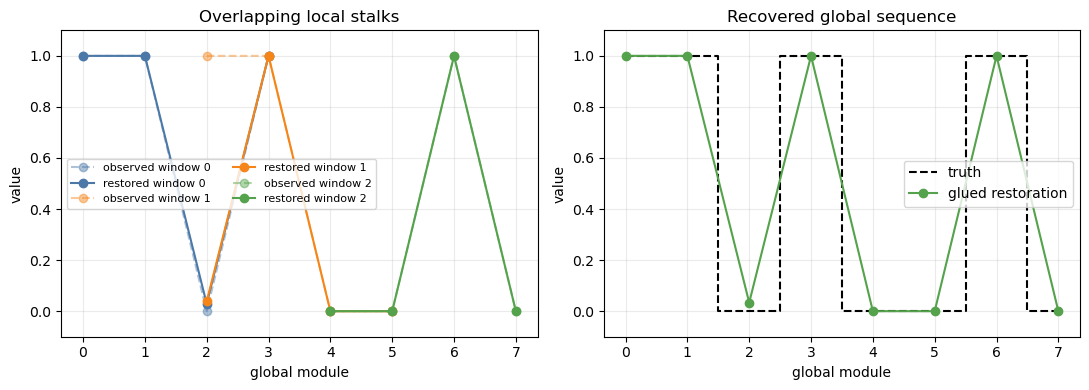

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ('#4C78A8', '#F58518', '#54A24B')
for window_index, (start, color) in enumerate(zip(window_starts, colors)):
    global_positions = np.arange(start, start + window_width)
    axes[0].plot(
        global_positions, observed_windows[window_index], 'o--',
        color=color, alpha=0.45, label=f'observed window {window_index}',
    )
    axes[0].plot(
        global_positions, restored_windows[window_index], 'o-',
        color=color, label=f'restored window {window_index}',
    )
axes[0].set(xticks=np.arange(len(binary_truth)), ylim=(-0.1, 1.1), xlabel='global module', ylabel='value', title='Overlapping local stalks')
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncol=2)

axes[1].step(np.arange(len(binary_truth)), binary_truth, where='mid', color='k', linestyle='--', label='truth')
axes[1].plot(np.arange(len(binary_truth)), glued_restoration, 'o-', color='#54A24B', label='glued restoration')
axes[1].set(xticks=np.arange(len(binary_truth)), ylim=(-0.1, 1.1), xlabel='global module', ylabel='value', title='Recovered global sequence')
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

## Gate 2 conclusion and checkpoint

Vector stalks and coordinate-selection restriction maps solve the conceptual problem exposed by Gate 1: the sheaf can preserve arbitrary barcode transitions while detecting contradictions only where local windows describe the same physical module. Confidence-weighted regularization can pull an unreliable local copy toward a trusted overlapping copy.

This is still a consistency experiment, not a camera model. The windows are perfectly aligned and their module coordinates are known. The next gate, only after review, is fixed multi-scanline fusion with a controlled damaged region. Blur, unknown module alignment, adaptive direction, and symbology decoding remain later work.

This notebook intentionally stops here.